<!-- notebook-header -->
# RNNs e LSTMs para NLP

**Modulo:** 05 - Dominios Aplicados / 05B - NLP  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Sequencias, RNN, LSTM, GRU, vanishing gradients e tarefas NLP sequenciais.


# 5B_3: RNNs e LSTMs para NLP

**Objetivo**: Compreender arquiteturas recorrentes para processamento de sequencias em NLP.

**Contexto**: Ate agora (5B_1, 5B_2) tratamos palavras isoladamente ou com representacoes
que ignoram ORDEM. Mas em linguagem, ordem importa: "gato come peixe" != "peixe come gato".
RNNs introduzem MEMORIA: cada passo leva em conta o contexto anterior.

**Neste notebook:**
1. Por que dados sequenciais precisam de arquiteturas especiais
2. RNN basica e o problema de vanishing gradient
3. LSTM: gates que controlam fluxo de informacao
4. GRU: simplificacao do LSTM
5. Arquiteturas (many-to-one, seq2seq, bidirectional)
6. Attention: precursor dos Transformers
7. Exercicios praticos com implementacoes numpy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
np.random.seed(42)

## 1. Por que Dados Sequenciais sao Diferentes

### Analogia
Imagine ler uma frase palavra por palavra. Cada palavra que voce le MUDA o significado
das proximas. "Eu fui ao banco" -- banco de que? So sabemos ao ler o CONTEXTO depois.
Um feedforward network trata cada palavra IGUALMENTE, sem ordem. E como embaralhar as
palavras e tentar entender a frase.

### Definicao Formal
Uma sequencia x = (x_1, x_2, ..., x_T) tem dependencias temporais:
- P(x_t | x_1, ..., x_{t-1}) != P(x_t) -- cada elemento depende dos anteriores
- A ORDEM importa: permutar a sequencia muda o significado

### Por que em ML
Feedforward networks tratam input como vetor FIXO. Para sequencias de tamanho variavel
com dependencias temporais, precisamos de arquiteturas que mantenham um ESTADO interno
que evolui ao processar cada elemento.

In [2]:
# Demonstrar por que ordem importa em sequencias
frases = [
    ("gato come peixe", "sujeito=gato, acao=come, objeto=peixe"),
    ("peixe come gato", "sujeito=peixe, acao=come, objeto=gato"),
    ("come gato peixe", "??? -- mesmas palavras, ordem diferente, sentido muda")
]

print("POR QUE ORDEM IMPORTA:")
print("=" * 60)
for frase, significado in frases:
    palavras = frase.split()
    print(f'Frase: "{frase}"')
    print(f'  Palavras: {palavras}')
    print(f'  Significado: {significado}')
    print()

# BoW perde ordem completamente
from collections import Counter
bow1 = Counter("gato come peixe".split())
bow2 = Counter("peixe come gato".split())
print(f"BoW de 'gato come peixe': {dict(bow1)}")
print(f"BoW de 'peixe come gato': {dict(bow2)}")
print(f"Sao iguais? {bow1 == bow2} -- BoW perde a informacao de ORDEM!")

POR QUE ORDEM IMPORTA:
Frase: "gato come peixe"
  Palavras: ['gato', 'come', 'peixe']
  Significado: sujeito=gato, acao=come, objeto=peixe

Frase: "peixe come gato"
  Palavras: ['peixe', 'come', 'gato']
  Significado: sujeito=peixe, acao=come, objeto=gato

Frase: "come gato peixe"
  Palavras: ['come', 'gato', 'peixe']
  Significado: ??? -- mesmas palavras, ordem diferente, sentido muda

BoW de 'gato come peixe': {'gato': 1, 'come': 1, 'peixe': 1}
BoW de 'peixe come gato': {'peixe': 1, 'come': 1, 'gato': 1}
Sao iguais? True -- BoW perde a informacao de ORDEM!


### O que observar sobre a Natureza dos Dados Sequenciais

Dados sequenciais aparecem em MUITAS areas alem de NLP:
- **Texto:** cada palavra depende das anteriores
- **Audio:** fonemas formam palavras, palavras formam frases
- **Video:** frames consecutivos tem continuidade
- **Financas:** precos dependem do historico
- **Biologia:** sequencias de DNA/proteinas

### O que concluir sobre Representacoes que Preservam Ordem

BoW e TF-IDF (5B_1) perdem TODA informacao de ordem. Embeddings (5B_2) representam
palavras isoladas. Para capturar SEQUENCIAS, precisamos de modelos que mantenham
um estado que evolui ao processar cada elemento -- isso e a essencia das RNNs.

### Conexao com outros notebooks sobre Features Sequenciais

Dados sequenciais sao fundamentalmente diferentes de dados tabulares (1_4 feature
engineering). Em dados tabulares, features sao independentes. Em sequencias, a POSICAO
e o CONTEXTO de cada feature importam tanto quanto seu valor.

## 2. RNN Basica (Recurrent Neural Network)

### Analogia
Pense em ler um livro: a cada pagina, voce atualiza seu ENTENDIMENTO do livro.
Esse entendimento acumulado e o "hidden state". Cada nova palavra atualiza o hidden
state levando em conta o que veio antes.

### Definicao Formal
A cada timestep t:
- h_t = tanh(W_hh * h_{t-1} + W_xh * x_t + b_h)
- y_t = W_hy * h_t + b_y

Onde h_t e o hidden state (memoria) e x_t e o input no timestep t.
W_hh, W_xh, W_hy sao matrizes de pesos COMPARTILHADAS entre todos os timesteps.

### Por que em ML
O compartilhamento de pesos permite processar sequencias de QUALQUER tamanho
com o mesmo numero de parametros. Mas tem um preco: vanishing/exploding gradients.

In [3]:
# RNN implementada do zero com numpy
class SimpleRNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_size = hidden_size
        # Inicializacao Xavier
        scale_h = np.sqrt(2.0 / (hidden_size + hidden_size))
        scale_x = np.sqrt(2.0 / (input_size + hidden_size))
        scale_y = np.sqrt(2.0 / (hidden_size + output_size))

        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale_h
        self.W_xh = np.random.randn(hidden_size, input_size) * scale_x
        self.W_hy = np.random.randn(output_size, hidden_size) * scale_y
        self.b_h = np.zeros(hidden_size)
        self.b_y = np.zeros(output_size)

    def forward(self, x_seq):
        T = len(x_seq)
        h = np.zeros(self.hidden_size)
        hidden_states = [h.copy()]
        outputs = []

        for t in range(T):
            # h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t + b)
            h = np.tanh(self.W_hh @ h + self.W_xh @ x_seq[t] + self.b_h)
            y = self.W_hy @ h + self.b_y
            hidden_states.append(h.copy())
            outputs.append(y)

        return np.array(outputs), np.array(hidden_states)

# Teste: processar sequencia de 5 timesteps
rnn = SimpleRNN(input_size=3, hidden_size=4, output_size=2)
x_seq = np.random.randn(5, 3)  # 5 timesteps, 3 features cada

outputs, hidden_states = rnn.forward(x_seq)

print("RNN Basica - Forward Pass")
print(f"  Input shape: {x_seq.shape} (T=5 timesteps, D=3 features)")
print(f"  Output shape: {outputs.shape} (T=5 timesteps, O=2 outputs)")
print(f"  Hidden states shape: {hidden_states.shape} (T+1 estados, H=4 dimensoes)")
print()
print("Hidden states evoluem ao processar cada timestep:")
for t in range(len(hidden_states)):
    print(f"  t={t}: h = [{', '.join(f'{v:.3f}' for v in hidden_states[t])}]")

RNN Basica - Forward Pass
  Input shape: (5, 3) (T=5 timesteps, D=3 features)
  Output shape: (5, 2) (T=5 timesteps, O=2 outputs)
  Hidden states shape: (6, 4) (T+1 estados, H=4 dimensoes)

Hidden states evoluem ao processar cada timestep:
  t=0: h = [0.000, 0.000, 0.000, 0.000]
  t=1: h = [0.200, -0.911, 0.955, 0.740]
  t=2: h = [0.726, 0.911, -0.860, -0.496]
  t=3: h = [0.188, -0.774, 0.781, -0.021]
  t=4: h = [0.136, 0.624, -0.391, 0.500]
  t=5: h = [-0.376, -0.955, 0.879, 0.656]


### O que observar sobre Vanishing Gradient

O problema fundamental das RNNs: durante backpropagation through time (BPTT),
gradientes sao multiplicados pela mesma matriz W_hh repetidamente.
Se os eigenvalues de W_hh < 1, gradientes ENCOLHEM exponencialmente.
Se > 1, EXPLODEM. Isso limita RNNs a sequencias curtas (~20-50 tokens).

### Por que em ML
Vanishing gradient significa que a RNN NAO CONSEGUE aprender dependencias de longo
prazo. Se uma informacao no timestep 0 e crucial para o timestep 50, o gradiente
sera tao pequeno que os pesos nao atualizam. Isso motivou a criacao do LSTM.

In [4]:

# Demonstrar vanishing gradient
def compute_gradients_rnn(seq_length, hidden_size):
    # Simular multiplicação de matrizes
    # gradient = W^T * W^T * ... * W^T (seq_length vezes)
    W = np.eye(hidden_size) * 0.9  # Eigenvalues < 1
    
    gradient_norm = []
    grad = np.ones((hidden_size, 1))
    
    for t in range(seq_length):
        grad = W.T @ grad
        gradient_norm.append(np.linalg.norm(grad))
    
    return gradient_norm

seq_length = 50
hidden_size = 10

grad_norms = compute_gradients_rnn(seq_length, hidden_size)

print("Norma de gradientes através do tempo:")
print(f"  t=0: {grad_norms[0]:.6f}")
print(f"  t=10: {grad_norms[10]:.6f}")
print(f"  t=30: {grad_norms[30]:.6f}")
print(f"  t=49: {grad_norms[49]:.6f}")
print("\nGradientes desaparecem! -> Problema de vanishing gradient")


Norma de gradientes através do tempo:
  t=0: 2.846050
  t=10: 0.992356
  t=30: 0.120647
  t=49: 0.016298

Gradientes desaparecem! -> Problema de vanishing gradient


### O que concluir sobre as Implicacoes Praticas do Vanishing Gradient

Na pratica, vanishing gradient significa:
- RNN basica so funciona bem para sequencias curtas (< 20-30 tokens)
- Informacoes no INICIO da sequencia sao "esquecidas"
- Treinar RNNs profundas (muitas camadas) e muito dificil
- Gradient clipping resolve EXPLODING mas NAO vanishing

### Conexao com outros notebooks sobre Inicializacao de Pesos

Vanishing gradient em RNNs conecta com 2_3 (inicializacao). Pesos inicializados
muito pequenos agravam o problema. Orthogonal initialization (W_hh ortogonal)
e a melhor pratica para RNNs, porque preserva a norma dos gradientes.

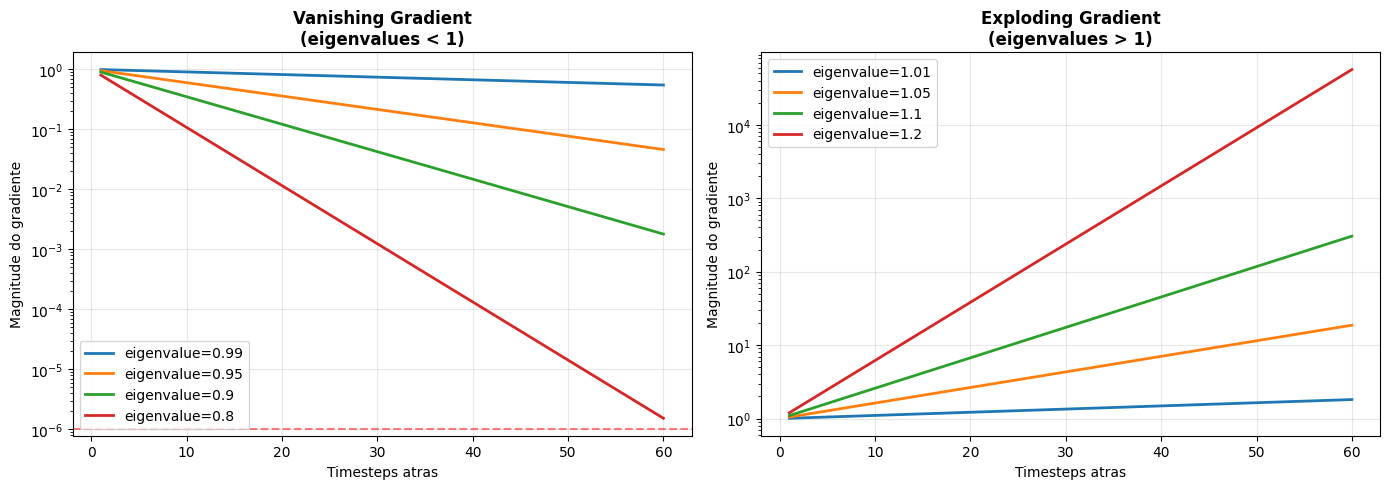

Com eigenvalue=0.9, apos 50 steps: gradiente = 0.9^50 = 0.00515377520732012
Com eigenvalue=1.1, apos 50 steps: gradiente = 1.1^50 = 117


In [5]:
# Visualizar vanishing vs exploding gradient
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seq_lengths = range(1, 61)

# Vanishing (eigenvalues < 1)
ax = axes[0]
for eigenval in [0.99, 0.95, 0.9, 0.8]:
    grads = [eigenval**t for t in seq_lengths]
    ax.plot(seq_lengths, grads, label=f'eigenvalue={eigenval}', linewidth=2)
ax.set_xlabel('Timesteps atras')
ax.set_ylabel('Magnitude do gradiente')
ax.set_title('Vanishing Gradient\n(eigenvalues < 1)', fontweight='bold')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.axhline(y=1e-6, color='red', linestyle='--', alpha=0.5, label='threshold pratico')

# Exploding (eigenvalues > 1)
ax = axes[1]
for eigenval in [1.01, 1.05, 1.1, 1.2]:
    grads = [eigenval**t for t in seq_lengths]
    ax.plot(seq_lengths, grads, label=f'eigenvalue={eigenval}', linewidth=2)
ax.set_xlabel('Timesteps atras')
ax.set_ylabel('Magnitude do gradiente')
ax.set_title('Exploding Gradient\n(eigenvalues > 1)', fontweight='bold')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/vanishing_exploding.png', dpi=100, bbox_inches='tight')
plt.show()

print("Com eigenvalue=0.9, apos 50 steps: gradiente = 0.9^50 =", 0.9**50)
print("Com eigenvalue=1.1, apos 50 steps: gradiente = 1.1^50 =", f"{1.1**50:.0f}")

## 3. LSTM (Long Short-Term Memory)

### Analogia
LSTM e como um caderno com borracha seletiva. Voce tem 3 decisoes a cada momento:
1. **Forget gate** (borracha): "que partes do que anotei devo apagar?"
2. **Input gate** (caneta): "que informacao nova devo anotar?"
3. **Output gate** (janela): "que parte das anotacoes devo mostrar agora?"

O caderno (cell state c_t) persiste, passando informacao ao longo da sequencia
sem ser multiplicado repetidamente pela mesma matriz -- e por isso o gradiente
NAO desaparece tao rapido.

### Definicao Formal
A cada timestep t, com input x_t e hidden state h_{t-1}:
- f_t = sigmoid(W_f @ [h_{t-1}, x_t] + b_f)  -- forget gate
- i_t = sigmoid(W_i @ [h_{t-1}, x_t] + b_i)  -- input gate
- c_tilde = tanh(W_c @ [h_{t-1}, x_t] + b_c)  -- candidato
- c_t = f_t * c_{t-1} + i_t * c_tilde  -- cell state (SOMA, nao multiplicacao!)
- o_t = sigmoid(W_o @ [h_{t-1}, x_t] + b_o)  -- output gate
- h_t = o_t * tanh(c_t)  -- hidden state

### Por que em ML
A chave e c_t = f_t * c_{t-1} + i_t * c_tilde. O gradiente de c_t para c_{t-1}
e f_t (um numero entre 0 e 1 controlado pelo forget gate). Se f_t ~ 1, o gradiente
passa SEM diminuir. Gates APRENDEM quando esquecer e quando lembrar.

In [6]:
# LSTM implementada do zero com numpy
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

class SimpleLSTM:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        combined = input_size + hidden_size
        scale = np.sqrt(2.0 / combined)

        # Forget gate
        self.W_f = np.random.randn(hidden_size, combined) * scale
        self.b_f = np.ones(hidden_size)  # Bias alto = lembrar por padrao

        # Input gate
        self.W_i = np.random.randn(hidden_size, combined) * scale
        self.b_i = np.zeros(hidden_size)

        # Cell candidate
        self.W_c = np.random.randn(hidden_size, combined) * scale
        self.b_c = np.zeros(hidden_size)

        # Output gate
        self.W_o = np.random.randn(hidden_size, combined) * scale
        self.b_o = np.zeros(hidden_size)

    def forward(self, x_seq):
        T = len(x_seq)
        h = np.zeros(self.hidden_size)
        c = np.zeros(self.hidden_size)

        hidden_states = []
        cell_states = []
        gate_history = {'forget': [], 'input': [], 'output': []}

        for t in range(T):
            combined = np.concatenate([h, x_seq[t]])

            # Gates
            f_t = sigmoid(self.W_f @ combined + self.b_f)
            i_t = sigmoid(self.W_i @ combined + self.b_i)
            c_tilde = np.tanh(self.W_c @ combined + self.b_c)
            o_t = sigmoid(self.W_o @ combined + self.b_o)

            # Update cell state (SOMA, nao multiplicacao pura!)
            c = f_t * c + i_t * c_tilde

            # Update hidden state
            h = o_t * np.tanh(c)

            hidden_states.append(h.copy())
            cell_states.append(c.copy())
            gate_history['forget'].append(f_t.copy())
            gate_history['input'].append(i_t.copy())
            gate_history['output'].append(o_t.copy())

        return np.array(hidden_states), np.array(cell_states), gate_history

# Teste
lstm = SimpleLSTM(input_size=3, hidden_size=4)
x_seq = np.random.randn(8, 3)

h_states, c_states, gates = lstm.forward(x_seq)

print("LSTM - Forward Pass (8 timesteps)")
print(f"  Hidden states shape: {h_states.shape}")
print(f"  Cell states shape: {c_states.shape}")
print()
print("Gates ao longo do tempo (dimensao 0):")
print(f"  Forget gate: {[f'{g[0]:.3f}' for g in gates['forget']]}")
print(f"  Input gate:  {[f'{g[0]:.3f}' for g in gates['input']]}")
print(f"  Output gate: {[f'{g[0]:.3f}' for g in gates['output']]}")
print()
print("Forget gate alto (~1) = LEMBRAR informacao anterior")
print("Input gate alto (~1) = ACEITAR informacao nova")
print("Output gate alto (~1) = EXPOR cell state como output")

LSTM - Forward Pass (8 timesteps)
  Hidden states shape: (8, 4)
  Cell states shape: (8, 4)

Gates ao longo do tempo (dimensao 0):
  Forget gate: ['0.523', '0.651', '0.772', '0.705', '0.779', '0.345', '0.710', '0.565']
  Input gate:  ['0.426', '0.267', '0.721', '0.550', '0.421', '0.176', '0.606', '0.324']
  Output gate: ['0.720', '0.444', '0.480', '0.531', '0.597', '0.694', '0.706', '0.667']

Forget gate alto (~1) = LEMBRAR informacao anterior
Input gate alto (~1) = ACEITAR informacao nova
Output gate alto (~1) = EXPOR cell state como output


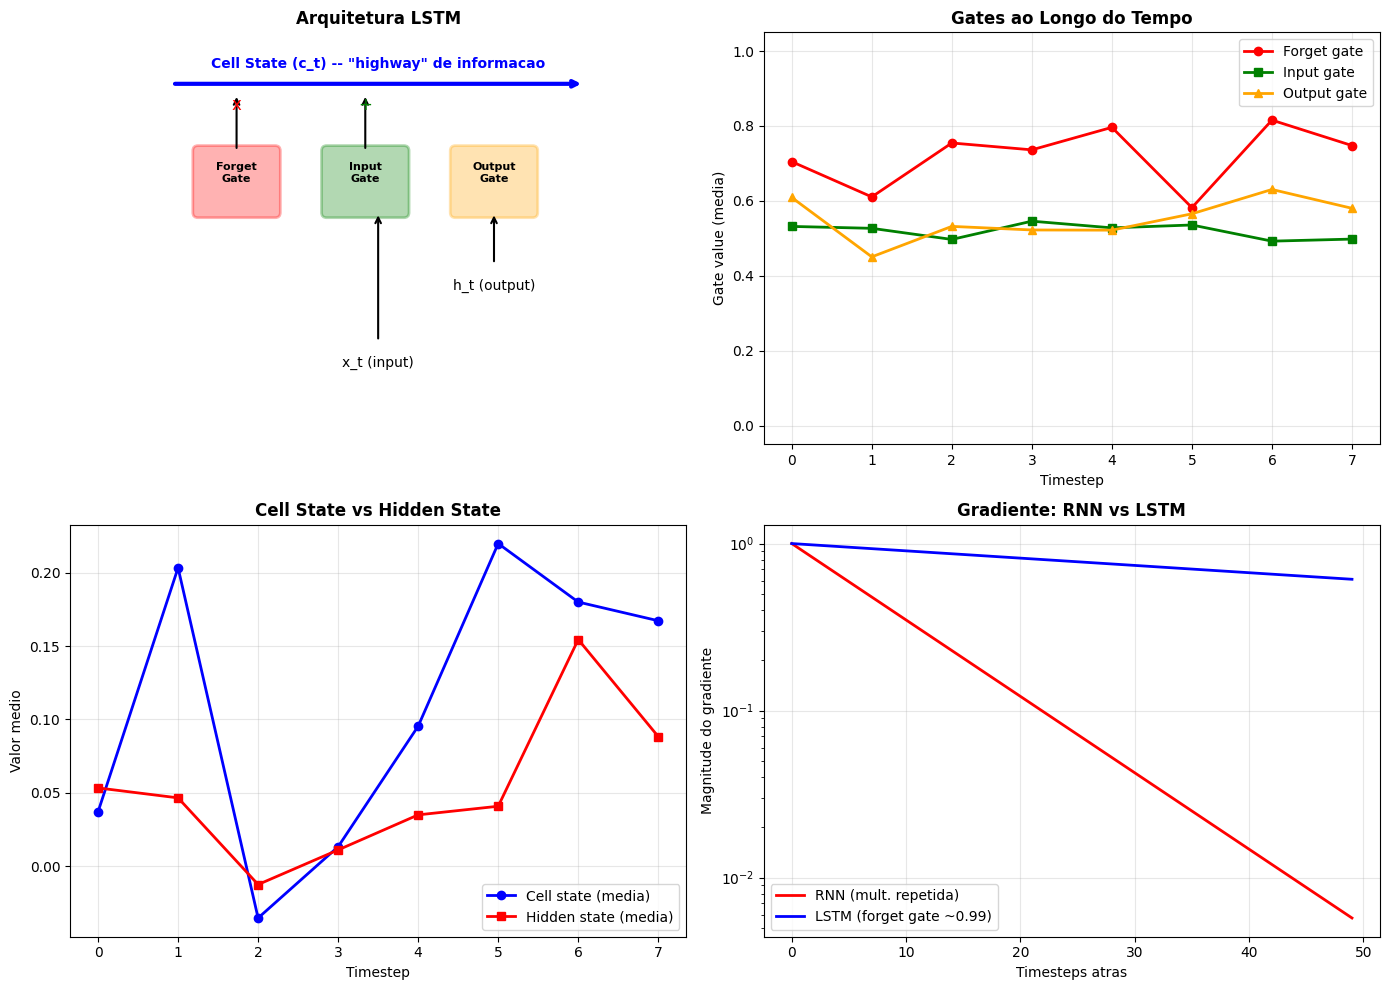

LSTM resolve vanishing gradient porque:
  1. Cell state usa SOMA (c_t = f*c + i*c~), nao multiplicacao pura
  2. Gradiente de c_t para c_{t-1} = f_t (controlado, proximo de 1)
  3. Gates APRENDEM quando esquecer e quando lembrar


In [7]:
# Visualizar como LSTM gates controlam fluxo de informacao
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Diagrama LSTM
ax = axes[0, 0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.set_aspect('equal')

# Cell state (highway)
ax.annotate('', xy=(9, 7), xytext=(1, 7),
            arrowprops=dict(arrowstyle='->', color='blue', lw=3))
ax.text(5, 7.3, 'Cell State (c_t) -- "highway" de informacao', ha='center',
        fontsize=10, fontweight='bold', color='blue')

# Forget gate
rect_f = patches.FancyBboxPatch((1.5, 4.5), 1.5, 1.2, boxstyle="round,pad=0.1",
                                 facecolor='red', alpha=0.3, edgecolor='red', lw=2)
ax.add_patch(rect_f)
ax.text(2.25, 5.1, 'Forget\nGate', ha='center', fontsize=8, fontweight='bold')

# Input gate
rect_i = patches.FancyBboxPatch((4, 4.5), 1.5, 1.2, boxstyle="round,pad=0.1",
                                 facecolor='green', alpha=0.3, edgecolor='green', lw=2)
ax.add_patch(rect_i)
ax.text(4.75, 5.1, 'Input\nGate', ha='center', fontsize=8, fontweight='bold')

# Output gate
rect_o = patches.FancyBboxPatch((6.5, 4.5), 1.5, 1.2, boxstyle="round,pad=0.1",
                                 facecolor='orange', alpha=0.3, edgecolor='orange', lw=2)
ax.add_patch(rect_o)
ax.text(7.25, 5.1, 'Output\nGate', ha='center', fontsize=8, fontweight='bold')

# Arrows
ax.annotate('', xy=(2.25, 6.8), xytext=(2.25, 5.7), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(4.75, 6.8), xytext=(4.75, 5.7), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(7.25, 4.5), xytext=(7.25, 3.5), arrowprops=dict(arrowstyle='->', lw=1.5))

ax.text(2.25, 6.5, 'x', ha='center', fontsize=12, color='red')
ax.text(4.75, 6.5, '+', ha='center', fontsize=12, color='green')

# Input
ax.annotate('', xy=(5, 4.5), xytext=(5, 2), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(5, 1.5, 'x_t (input)', ha='center', fontsize=10)

# Output
ax.text(7.25, 3, 'h_t (output)', ha='center', fontsize=10)

ax.set_title('Arquitetura LSTM', fontsize=12, fontweight='bold')
ax.axis('off')

# 2. Gates ao longo do tempo
ax = axes[0, 1]
T = len(gates['forget'])
timesteps = range(T)
ax.plot(timesteps, [g.mean() for g in gates['forget']], 'r-o', label='Forget gate', linewidth=2)
ax.plot(timesteps, [g.mean() for g in gates['input']], 'g-s', label='Input gate', linewidth=2)
ax.plot(timesteps, [g.mean() for g in gates['output']], 'orange', marker='^', label='Output gate', linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Gate value (media)')
ax.set_title('Gates ao Longo do Tempo', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# 3. Cell state vs hidden state
ax = axes[1, 0]
ax.plot(timesteps, [c.mean() for c in c_states], 'b-o', label='Cell state (media)', linewidth=2)
ax.plot(timesteps, [h.mean() for h in h_states], 'r-s', label='Hidden state (media)', linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Valor medio')
ax.set_title('Cell State vs Hidden State', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Por que LSTM resolve vanishing gradient
ax = axes[1, 1]
# Simular gradiente passando pelo cell state
T_sim = 50
grad_rnn = [0.9**t for t in range(T_sim)]
grad_lstm = [0.99**t for t in range(T_sim)]  # forget gate ~ 0.99
ax.plot(range(T_sim), grad_rnn, 'r-', label='RNN (mult. repetida)', linewidth=2)
ax.plot(range(T_sim), grad_lstm, 'b-', label='LSTM (forget gate ~0.99)', linewidth=2)
ax.set_xlabel('Timesteps atras')
ax.set_ylabel('Magnitude do gradiente')
ax.set_title('Gradiente: RNN vs LSTM', fontweight='bold')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/lstm_gates.png', dpi=100, bbox_inches='tight')
plt.show()

print("LSTM resolve vanishing gradient porque:")
print("  1. Cell state usa SOMA (c_t = f*c + i*c~), nao multiplicacao pura")
print("  2. Gradiente de c_t para c_{t-1} = f_t (controlado, proximo de 1)")
print("  3. Gates APRENDEM quando esquecer e quando lembrar")

### O que observar sobre o Forget Gate Bias

Na pratica, inicializa-se o bias do forget gate com valor ALTO (1.0 ou 2.0).
Isso faz f_t comecar proximo de 1, significando "lembrar tudo por padrao".
Sem isso, LSTM pode "esquecer" informacoes antes de aprender a lembra-las.

### O que concluir sobre Cell State como Highway de Informacao

O cell state funciona como uma "rodovia" de informacao: a informacao pode
fluir ao longo de toda a sequencia quase sem modificacao (quando f_t ~ 1).
Isso e fundamentalmente diferente da RNN onde h_t e SEMPRE transformado
por tanh, comprimindo informacao a cada passo.

### Conexao com outros notebooks sobre Residual Connections

O cell state do LSTM e conceitualmente similar a residual connections (5A_1):
c_t = f*c + i*c~ e uma soma (como x + F(x) em ResNets). Ambos resolvem
o mesmo problema: permitir que gradientes fluam sem degradacao.

## 4. GRU (Gated Recurrent Unit)

### Analogia
Se LSTM e um caderno com 3 ferramentas (borracha, caneta, janela), GRU e um caderno
com 2 ferramentas: uma que decide "quanto do velho manter" (update gate) e outra
que decide "quanto acesso tenho ao estado anterior" (reset gate). Mais simples,
mais rapido, frequentemente tao bom quanto LSTM.

### Definicao Formal
- z_t = sigmoid(W_z @ [h_{t-1}, x_t])  -- update gate
- r_t = sigmoid(W_r @ [h_{t-1}, x_t])  -- reset gate
- h_tilde = tanh(W_h @ [r_t * h_{t-1}, x_t])  -- candidato
- h_t = (1 - z_t) * h_{t-1} + z_t * h_tilde  -- interpolacao!

### Por que em ML
GRU tem ~25% menos parametros que LSTM (2 gates vs 3). Na pratica, performance
e similar para a maioria das tarefas. GRU e preferido quando velocidade importa
ou quando dados sao limitados (menos parametros = menos overfitting).

In [8]:
# GRU implementado do zero com numpy
class SimpleGRU:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        combined = input_size + hidden_size
        scale = np.sqrt(2.0 / combined)

        # Update gate
        self.W_z = np.random.randn(hidden_size, combined) * scale
        self.b_z = np.zeros(hidden_size)

        # Reset gate
        self.W_r = np.random.randn(hidden_size, combined) * scale
        self.b_r = np.zeros(hidden_size)

        # Candidate hidden state
        self.W_h = np.random.randn(hidden_size, combined) * scale
        self.b_h = np.zeros(hidden_size)

    def forward(self, x_seq):
        T = len(x_seq)
        h = np.zeros(self.hidden_size)
        hidden_states = []

        for t in range(T):
            combined = np.concatenate([h, x_seq[t]])

            # Gates
            z_t = sigmoid(self.W_z @ combined + self.b_z)  # update
            r_t = sigmoid(self.W_r @ combined + self.b_r)  # reset

            # Candidate (usa reset gate para controlar acesso ao h anterior)
            combined_r = np.concatenate([r_t * h, x_seq[t]])
            h_tilde = np.tanh(self.W_h @ combined_r + self.b_h)

            # Interpolacao entre h anterior e candidato
            h = (1 - z_t) * h + z_t * h_tilde
            hidden_states.append(h.copy())

        return np.array(hidden_states)

# Comparar RNN vs LSTM vs GRU
np.random.seed(42)
x_seq = np.random.randn(10, 3)

rnn = SimpleRNN(3, 8, 2)
lstm = SimpleLSTM(3, 8)
gru = SimpleGRU(3, 8)

rnn_out, _ = rnn.forward(x_seq)
lstm_out, _, _ = lstm.forward(x_seq)
gru_out = gru.forward(x_seq)

# Contar parametros
def count_params(model):
    total = 0
    for attr in dir(model):
        val = getattr(model, attr)
        if isinstance(val, np.ndarray):
            total += val.size
    return total

print("Comparacao RNN vs LSTM vs GRU (hidden_size=8, input_size=3):")
print(f"  RNN:  {count_params(rnn):>5} parametros")
print(f"  LSTM: {count_params(lstm):>5} parametros")
print(f"  GRU:  {count_params(gru):>5} parametros")
print(f"  LSTM/RNN ratio: {count_params(lstm)/count_params(rnn):.1f}x")
print(f"  GRU/RNN ratio:  {count_params(gru)/count_params(rnn):.1f}x")
print(f"  GRU/LSTM ratio: {count_params(gru)/count_params(lstm):.1f}x")

Comparacao RNN vs LSTM vs GRU (hidden_size=8, input_size=3):
  RNN:    114 parametros
  LSTM:   384 parametros
  GRU:    288 parametros
  LSTM/RNN ratio: 3.4x
  GRU/RNN ratio:  2.5x
  GRU/LSTM ratio: 0.8x


### O que observar sobre Trade-offs LSTM vs GRU

Empiricamente, LSTM e GRU tem performance SIMILAR na maioria das tarefas.
A regra pratica e: comece com GRU (mais rapido); se nao for suficiente,
tente LSTM. Em tarefas com dependencias muito longas, LSTM tende a ser melhor.

### O que concluir sobre a Importancia de Gates em Geral

O conceito de gates (valores entre 0 e 1 que controlam fluxo de informacao)
e fundamental em deep learning moderno: aparece em LSTM, GRU, Highway Networks,
e ate em Transformers (onde softmax funciona como um gate suave).

### Conexao com outros notebooks sobre Complexidade de Modelos

LSTM tem 4x mais parametros que RNN para o mesmo hidden_size (2_1 bias-variance).
Mais parametros = maior capacidade mas tambem maior risco de overfitting.
GRU e um compromisso: 3x parametros da RNN, 75% do LSTM.

## 5. Arquiteturas RNN para Diferentes Tarefas

### Por que em ML
A flexibilidade das RNNs vem de como CONECTAMOS inputs e outputs:

- **Many-to-one**: Toda a sequencia -> uma decisao (classificacao de sentimento)
- **One-to-many**: Um input -> sequencia (geracao de texto)
- **Many-to-many**: Sequencia -> sequencia (traducao, NER)
- **Bidirectional**: Contexto anterior E posterior (BERT usa isso!)

### O que observar
Na pratica, many-to-one (usando o ULTIMO hidden state) e o mais comum para
classificacao. Para sequencias longas, bidirectional melhora muito porque
cada posicao tem acesso ao contexto COMPLETO.

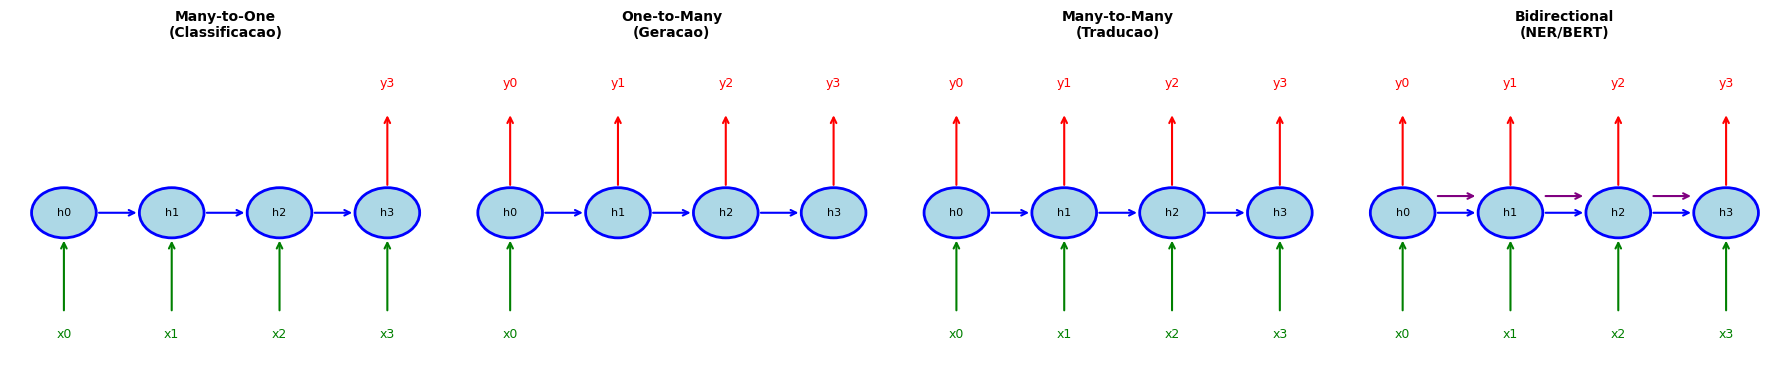

Arquiteturas RNN:
  Many-to-one: input=(x0..xT) -> output=y_T (sentimento, classificacao)
  One-to-many: input=x_0 -> output=(y0..yT) (geracao de musica/texto)
  Many-to-many: input=(x0..xT) -> output=(y0..yT) (traducao, NER)
  Bidirectional: processa frente E tras, cada h_t ve contexto completo


In [9]:
# Visualizar diferentes arquiteturas RNN
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

def draw_rnn_arch(ax, title, inputs, outputs, connections):
    ax.set_xlim(-0.5, max(len(inputs), len(outputs)) - 0.5)
    ax.set_ylim(-0.5, 3.5)

    # Hidden states
    n_hidden = max(len(inputs), len(outputs))
    for i in range(n_hidden):
        circle = plt.Circle((i, 1.5), 0.3, facecolor='lightblue', edgecolor='blue', lw=2)
        ax.add_patch(circle)
        ax.text(i, 1.5, f'h{i}', ha='center', va='center', fontsize=8)
        if i > 0:
            ax.annotate('', xy=(i-0.3, 1.5), xytext=(i-0.7, 1.5),
                       arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))

    # Inputs
    for i in inputs:
        ax.annotate('', xy=(i, 1.2), xytext=(i, 0.3),
                   arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
        ax.text(i, 0, f'x{i}', ha='center', fontsize=9, color='green')

    # Outputs
    for i in outputs:
        ax.annotate('', xy=(i, 2.7), xytext=(i, 1.8),
                   arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
        ax.text(i, 3, f'y{i}', ha='center', fontsize=9, color='red')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

draw_rnn_arch(axes[0], 'Many-to-One\n(Classificacao)', [0,1,2,3], [3], {})
draw_rnn_arch(axes[1], 'One-to-Many\n(Geracao)', [0], [0,1,2,3], {})
draw_rnn_arch(axes[2], 'Many-to-Many\n(Traducao)', [0,1,2,3], [0,1,2,3], {})
draw_rnn_arch(axes[3], 'Bidirectional\n(NER/BERT)', [0,1,2,3], [0,1,2,3], {})

# Add backward arrows for bidirectional
ax = axes[3]
for i in range(3):
    ax.annotate('', xy=(i+0.7, 1.7), xytext=(i+0.3, 1.7),
               arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))

plt.tight_layout()
plt.savefig('/tmp/rnn_architectures.png', dpi=100, bbox_inches='tight')
plt.show()

print("Arquiteturas RNN:")
print("  Many-to-one: input=(x0..xT) -> output=y_T (sentimento, classificacao)")
print("  One-to-many: input=x_0 -> output=(y0..yT) (geracao de musica/texto)")
print("  Many-to-many: input=(x0..xT) -> output=(y0..yT) (traducao, NER)")
print("  Bidirectional: processa frente E tras, cada h_t ve contexto completo")

## 6. Mecanismo de Attention (Precursor dos Transformers)

### Analogia
Imagine traduzir uma frase longa. Sem attention, o tradutor COMPRIME toda a frase
em uma unica nota mental (hidden state) e traduz a partir dela. Com attention,
o tradutor pode OLHAR DE VOLTA para partes especificas da frase original enquanto
traduz cada palavra. "Qual palavra do input e mais relevante para a palavra que
estou traduzindo AGORA?"

### Definicao Formal
Para um decoder no timestep t com hidden state s_t e encoder outputs (h_1,...,h_n):
- score(s_t, h_i) = s_t^T @ h_i  (dot-product attention)
- alpha_i = softmax(scores)  -- pesos de atencao
- context_t = sum(alpha_i * h_i)  -- vetor de contexto

### Por que em ML
Attention resolve o gargalo de comprimir toda a informacao em um unico vetor.
E a ideia central que levou aos Transformers (5B_4): "por que nao usar APENAS
attention, sem recorrencia?" -> "Attention is All You Need" (Vaswani et al., 2017).

In [10]:
# Mecanismo de Attention implementado com numpy
def dot_product_attention(query, keys, values):
    # query: (hidden_size,) -- decoder hidden state
    # keys: (T, hidden_size) -- encoder hidden states
    # values: (T, hidden_size) -- encoder hidden states (geralmente = keys)

    d_k = query.shape[0]

    # Scores: similaridade entre query e cada key
    scores = keys @ query / np.sqrt(d_k)  # (T,) -- scaled dot-product

    # Softmax -> pesos de atencao
    exp_scores = np.exp(scores - scores.max())  # estabilidade numerica
    attention_weights = exp_scores / exp_scores.sum()  # (T,)

    # Vetor de contexto: media ponderada dos values
    context = attention_weights @ values  # (hidden_size,)

    return context, attention_weights

# Simular encoder-decoder com attention
np.random.seed(42)
T_enc = 6  # frase de 6 palavras no encoder
hidden_size = 4

# Encoder outputs (simulados)
encoder_outputs = np.random.randn(T_enc, hidden_size)
palavras_input = ['o', 'gato', 'sentou', 'no', 'tapete', 'azul']

# Decoder hidden state (simulado)
decoder_hidden = np.random.randn(hidden_size)

context, weights = dot_product_attention(decoder_hidden, encoder_outputs, encoder_outputs)

print("Attention Mechanism")
print(f"  Encoder: {T_enc} palavras, hidden_size={hidden_size}")
print(f"  Decoder query: hidden_size={hidden_size}")
print(f"  Context vector: {context.shape}")
print()
print("Pesos de atencao por palavra:")
for i, (palavra, peso) in enumerate(zip(palavras_input, weights)):
    barra = '#' * int(peso * 50)
    print(f"  '{palavra:8s}': {peso:.3f} {barra}")
print()
print(f"Palavra com mais atencao: '{palavras_input[np.argmax(weights)]}'")

Attention Mechanism
  Encoder: 6 palavras, hidden_size=4
  Decoder query: hidden_size=4
  Context vector: (4,)

Pesos de atencao por palavra:
  'o       ': 0.114 #####
  'gato    ': 0.070 ###
  'sentou  ': 0.202 ##########
  'no      ': 0.294 ##############
  'tapete  ': 0.249 ############
  'azul    ': 0.070 ###

Palavra com mais atencao: 'no'


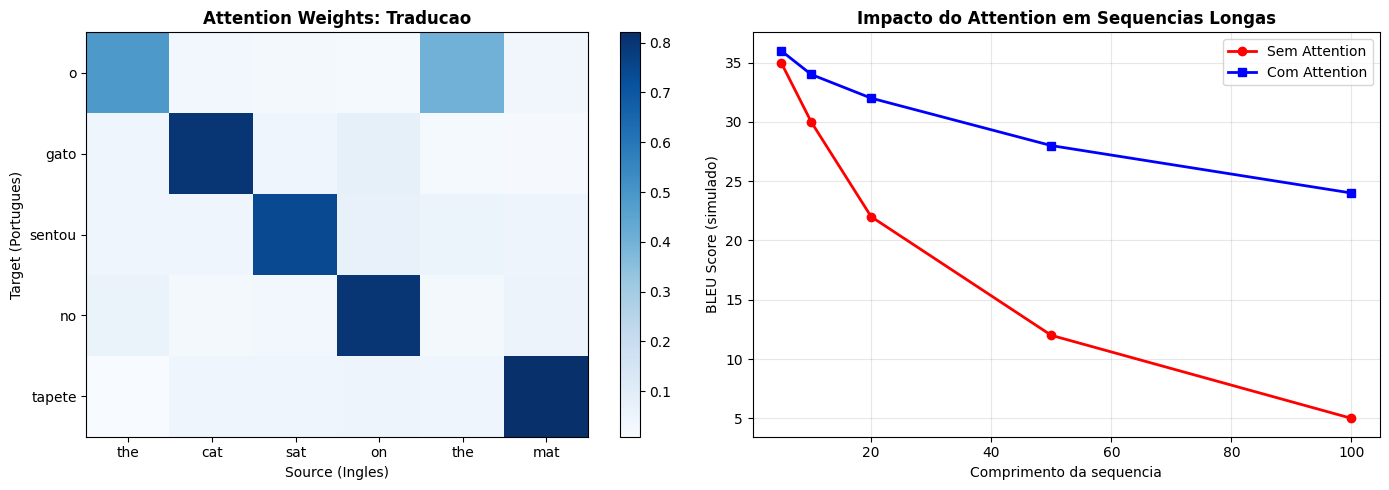

Attention e CRUCIAL para sequencias longas:
  Sem attention: BLEU degrada rapidamente com comprimento
  Com attention: mantem qualidade mesmo em frases longas
  Motivo: decoder pode OLHAR de volta para qualquer parte do input


In [11]:
# Visualizar attention em traducao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Attention heatmap (simulado)
ax = axes[0]
src_words = ['the', 'cat', 'sat', 'on', 'the', 'mat']
tgt_words = ['o', 'gato', 'sentou', 'no', 'tapete']

# Simular attention matrix
np.random.seed(123)
attention_matrix = np.zeros((len(tgt_words), len(src_words)))
# Criar alinhamento razoavel
alignments = [(0, 0), (0, 4), (1, 1), (2, 2), (3, 3), (4, 5)]
for t, s in alignments:
    attention_matrix[t, s] = 0.7 + np.random.rand() * 0.3
# Adicionar ruido
attention_matrix += np.random.rand(*attention_matrix.shape) * 0.1
# Normalizar por linha
attention_matrix = attention_matrix / attention_matrix.sum(axis=1, keepdims=True)

im = ax.imshow(attention_matrix, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(src_words)))
ax.set_xticklabels(src_words, fontsize=10)
ax.set_yticks(range(len(tgt_words)))
ax.set_yticklabels(tgt_words, fontsize=10)
ax.set_xlabel('Source (Ingles)')
ax.set_ylabel('Target (Portugues)')
ax.set_title('Attention Weights: Traducao', fontweight='bold')
plt.colorbar(im, ax=ax)

# 2. Sem attention vs com attention
ax = axes[1]
seq_lengths = [5, 10, 20, 50, 100]
bleu_no_attn = [35, 30, 22, 12, 5]
bleu_attn = [36, 34, 32, 28, 24]

ax.plot(seq_lengths, bleu_no_attn, 'r-o', label='Sem Attention', linewidth=2)
ax.plot(seq_lengths, bleu_attn, 'b-s', label='Com Attention', linewidth=2)
ax.set_xlabel('Comprimento da sequencia')
ax.set_ylabel('BLEU Score (simulado)')
ax.set_title('Impacto do Attention em Sequencias Longas', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/attention_viz.png', dpi=100, bbox_inches='tight')
plt.show()

print("Attention e CRUCIAL para sequencias longas:")
print("  Sem attention: BLEU degrada rapidamente com comprimento")
print("  Com attention: mantem qualidade mesmo em frases longas")
print("  Motivo: decoder pode OLHAR de volta para qualquer parte do input")

### O que observar sobre Diferentes Tipos de Attention

Existem varios tipos de attention usados na pratica:
- **Dot-product:** score = q^T @ k (mais simples, mais rapido)
- **Additive (Bahdanau):** score = v^T @ tanh(W_q @ q + W_k @ k)
- **Multiplicative (Luong):** score = q^T @ W @ k
- **Self-attention:** Q, K, V vem da MESMA sequencia (base do Transformer)

### O que concluir sobre Attention como Mecanismo Universal

Attention nao e especifico de NLP. E usado em:
- **Visao:** Vision Transformers (5A_5) aplicam self-attention a patches
- **Audio:** attention para speech recognition
- **Grafos:** Graph Attention Networks
- **Multimodal:** CLIP (5A_5) usa attention entre texto e imagem

### Conexao com outros notebooks sobre Self-Attention

No seq2seq, attention e do decoder para o encoder (cross-attention).
No Transformer (5B_4), SELF-attention aplica attention da sequencia para
ELA MESMA: cada palavra "presta atencao" em todas as outras palavras.

### Por que em ML o Attention e Tao Importante

Attention introduziu INTERPRETABILIDADE: pesos de attention mostram QUAIS
partes do input o modelo esta usando. Em aplicacoes medicas e juridicas,
isso e valioso para explicabilidade (4_3).

## 7. Exercicios Praticos

### Exercicio 1: Implementar RNN Forward Pass
Implemente o forward pass de uma RNN que processa uma sequencia
de palavras codificadas como one-hot vectors e retorna o hidden state final.

In [12]:
# PRATICA - Exercicio 1: RNN Forward Pass
# Implemente a funcao rnn_forward que processa uma sequencia

def rnn_forward(x_seq, W_hh, W_xh, b_h):
    # x_seq: (T, input_size) - sequencia de inputs
    # W_hh: (hidden_size, hidden_size) - pesos hidden-to-hidden
    # W_xh: (hidden_size, input_size) - pesos input-to-hidden
    # b_h: (hidden_size,) - bias
    # Retorna: hidden_states (T, hidden_size)
    hidden_size = W_hh.shape[0]
    T = len(x_seq)

    # TAREFA DO ALUNO: inicializar h como vetor de zeros
    h = None
    hidden_states = []

    for t in range(T):
        # TAREFA DO ALUNO: calcular h_t = tanh(W_hh @ h + W_xh @ x_t + b_h)
        h = None
        hidden_states.append(h)

    return np.array(hidden_states)

# Teste
W_hh = np.random.randn(4, 4) * 0.1
W_xh = np.random.randn(4, 3) * 0.1
b_h = np.zeros(4)
x_seq = np.random.randn(5, 3)

# result = rnn_forward(x_seq, W_hh, W_xh, b_h)
# print(f"Output shape: {result.shape}")  # Esperado: (5, 4)
print("Implemente rnn_forward acima!")

Implemente rnn_forward acima!


In [13]:
# SOLUCAO - Exercicio 1: RNN Forward Pass
def rnn_forward_sol(x_seq, W_hh, W_xh, b_h):
    hidden_size = W_hh.shape[0]
    T = len(x_seq)

    h = np.zeros(hidden_size)
    hidden_states = []

    for t in range(T):
        h = np.tanh(W_hh @ h + W_xh @ x_seq[t] + b_h)
        hidden_states.append(h.copy())

    return np.array(hidden_states)

# Teste
np.random.seed(42)
W_hh = np.random.randn(4, 4) * 0.1
W_xh = np.random.randn(4, 3) * 0.1
b_h = np.zeros(4)
x_seq = np.random.randn(5, 3)

result = rnn_forward_sol(x_seq, W_hh, W_xh, b_h)
print(f"RNN Forward Pass - SOLUCAO")
print(f"{'='*50}")
print(f"Input: {x_seq.shape} (5 timesteps, 3 features)")
print(f"Output: {result.shape} (5 hidden states, 4 dimensoes)")
print()
for t in range(len(result)):
    print(f"  h_{t}: [{', '.join(f'{v:.4f}' for v in result[t])}]")
print()
print("Cada h_t INCORPORA informacao de TAREFA DO ALUNOS os x_0..x_t anteriores")

RNN Forward Pass - SOLUCAO
Input: (5, 3) (5 timesteps, 3 features)
Output: (5, 4) (5 hidden states, 4 dimensoes)

  h_0: [0.1059, 0.0556, 0.0701, 0.0043]
  h_1: [-0.0821, -0.2280, 0.0665, -0.0380]
  h_2: [-0.1421, -0.2775, 0.1570, 0.1875]
  h_3: [0.1726, 0.1260, 0.1400, 0.1494]
  h_4: [-0.0202, -0.0499, -0.0278, -0.0682]

Cada h_t INCORPORA informacao de TAREFA DO ALUNOS os x_0..x_t anteriores


### Exercicio 2: LSTM Gates Manual
Dado um cenario especifico, calcule manualmente os valores dos gates
e o cell state resultante.

In [14]:
# PRATICA - Exercicio 2: LSTM Gates
# Cenario: processar a sequencia "eu gosto de gatos"
# Simular os gates para um timestep

# Valores pre-definidos (simplificados)
h_prev = np.array([0.5, -0.3, 0.1, 0.8])  # hidden state anterior
x_t = np.array([1.0, 0.0, 0.5])             # input "gatos" (embedding)
c_prev = np.array([0.2, 0.7, -0.1, 0.4])    # cell state anterior

# TAREFA DO ALUNO: Calcular forget gate (quanta info anterior manter?)
# Dica: se f_t ~ 1, mantem tudo. Se ~ 0, esquece tudo.
f_t = None  # np.array([?, ?, ?, ?])

# TAREFA DO ALUNO: Calcular input gate e candidato
i_t = None  # np.array([?, ?, ?, ?])
c_tilde = None  # np.array([?, ?, ?, ?])

# TAREFA DO ALUNO: Calcular novo cell state
# c_t = f_t * c_prev + i_t * c_tilde
c_t = None

# TAREFA DO ALUNO: Calcular output gate e hidden state
o_t = None
h_t = None  # o_t * tanh(c_t)

print("Calcule os gates manualmente!")

Calcule os gates manualmente!


In [15]:
# SOLUCAO - Exercicio 2: LSTM Gates
h_prev = np.array([0.5, -0.3, 0.1, 0.8])
x_t = np.array([1.0, 0.0, 0.5])
c_prev = np.array([0.2, 0.7, -0.1, 0.4])

# Forget gate: decidir quanto da info anterior manter
# Vamos simular que queremos manter bastante (valores altos)
f_t = np.array([0.9, 0.8, 0.3, 0.95])  # manter dim 0,1,3; esquecer dim 2

# Input gate: decidir quanto de info nova aceitar
i_t = np.array([0.7, 0.2, 0.9, 0.1])  # aceitar muito em dim 0,2

# Candidato: nova informacao
c_tilde = np.array([0.5, -0.1, 0.8, 0.3])

# Cell state: combinar velho (filtrado) + novo (filtrado)
c_t = f_t * c_prev + i_t * c_tilde
# c_t = [0.9*0.2 + 0.7*0.5, 0.8*0.7 + 0.2*(-0.1), 0.3*(-0.1) + 0.9*0.8, 0.95*0.4 + 0.1*0.3]

# Output gate: quanto do cell state expor
o_t = np.array([0.8, 0.6, 0.7, 0.9])

# Hidden state final
h_t = o_t * np.tanh(c_t)

print("LSTM Gates Manual - SOLUCAO")
print("=" * 50)
print(f"h_prev:  {h_prev}")
print(f"x_t:     {x_t}")
print(f"c_prev:  {c_prev}")
print()
print(f"Forget gate (f_t):  {f_t}")
print(f"  -> dim 2 = 0.3: ESQUECENDO info antiga nessa dimensao")
print(f"  -> dim 3 = 0.95: MANTENDO quase tudo")
print()
print(f"Input gate (i_t):   {i_t}")
print(f"Candidato (c~):     {c_tilde}")
print()
print(f"Cell state novo:")
for d in range(4):
    old = f_t[d] * c_prev[d]
    new = i_t[d] * c_tilde[d]
    print(f"  dim {d}: {f_t[d]:.1f}*{c_prev[d]:.1f} + {i_t[d]:.1f}*{c_tilde[d]:.1f} = {old:.3f} + {new:.3f} = {c_t[d]:.3f}")
print()
print(f"c_t:     {c_t}")
print(f"o_t:     {o_t}")
print(f"h_t:     {h_t}")

LSTM Gates Manual - SOLUCAO
h_prev:  [ 0.5 -0.3  0.1  0.8]
x_t:     [1.  0.  0.5]
c_prev:  [ 0.2  0.7 -0.1  0.4]

Forget gate (f_t):  [0.9  0.8  0.3  0.95]
  -> dim 2 = 0.3: ESQUECENDO info antiga nessa dimensao
  -> dim 3 = 0.95: MANTENDO quase tudo

Input gate (i_t):   [0.7 0.2 0.9 0.1]
Candidato (c~):     [ 0.5 -0.1  0.8  0.3]

Cell state novo:
  dim 0: 0.9*0.2 + 0.7*0.5 = 0.180 + 0.350 = 0.530
  dim 1: 0.8*0.7 + 0.2*-0.1 = 0.560 + -0.020 = 0.540
  dim 2: 0.3*-0.1 + 0.9*0.8 = -0.030 + 0.720 = 0.690
  dim 3: 0.9*0.4 + 0.1*0.3 = 0.380 + 0.030 = 0.410

c_t:     [0.53 0.54 0.69 0.41]
o_t:     [0.8 0.6 0.7 0.9]
h_t:     [0.38830487 0.29579278 0.4185874  0.34962541]


### Exercicio 3: Attention Weights
Implemente attention e verifique que os pesos somam 1.

In [16]:
# PRATICA - Exercicio 3: Attention
# Implementar dot-product attention

def compute_attention(query, keys):
    # query: (hidden_size,) - vetor do decoder
    # keys: (T, hidden_size) - vetores do encoder
    # Retorna: attention_weights (T,) que somam 1
    # TAREFA DO ALUNO: calcular scores = keys @ query
    scores = None

    # TAREFA DO ALUNO: aplicar softmax
    # Dica: softmax(x) = exp(x) / sum(exp(x))
    # Para estabilidade: subtrair max antes do exp
    weights = None

    return weights

# Teste
query = np.array([1.0, 0.5, -0.3, 0.8])
keys = np.random.randn(5, 4)

# weights = compute_attention(query, keys)
# print(f"Pesos: {weights}")
# print(f"Soma: {weights.sum():.6f}")  # Deve ser ~1.0
print("Implemente compute_attention acima!")

Implemente compute_attention acima!


In [17]:
# SOLUCAO - Exercicio 3: Attention
def compute_attention_sol(query, keys):
    # Scores: similaridade entre query e cada key
    scores = keys @ query  # (T,)

    # Softmax com estabilidade numerica
    scores_stable = scores - scores.max()
    exp_scores = np.exp(scores_stable)
    weights = exp_scores / exp_scores.sum()

    return weights

# Teste
np.random.seed(42)
query = np.array([1.0, 0.5, -0.3, 0.8])
keys = np.random.randn(5, 4)
palavras = ['o', 'gato', 'dormiu', 'no', 'sofa']

weights = compute_attention_sol(query, keys)

print("Attention Weights - SOLUCAO")
print("=" * 50)
print(f"Query: {query}")
print(f"Soma dos pesos: {weights.sum():.6f} (deve ser ~1.0)")
print()
for i, (p, w) in enumerate(zip(palavras, weights)):
    barra = '#' * int(w * 40)
    print(f"  '{p:8s}': {w:.4f} {barra}")
print()
print("Softmax garante que pesos sao positivos e somam 1")
print("Palavras mais 'similares' ao query recebem mais peso")

Attention Weights - SOLUCAO
Query: [ 1.   0.5 -0.3  0.8]
Soma dos pesos: 1.000000 (deve ser ~1.0)

  'o       ': 0.6638 ##########################
  'gato    ': 0.1259 #####
  'dormiu  ': 0.1009 ####
  'no      ': 0.0814 ###
  'sofa    ': 0.0280 #

Softmax garante que pesos sao positivos e somam 1
Palavras mais 'similares' ao query recebem mais peso


## 8. Erros Comuns e Armadilhas

### Erro 1: Sequencias longas mesmo com LSTM
**Problema:** LSTM melhora, mas nao resolve completamente para T > 500 tokens.
**Solucao:** Truncar sequencias, usar attention, ou migrar para Transformers.

### Erro 2: Nao usar gradient clipping
**Problema:** Exploding gradients causam NaN durante treinamento de RNNs.
**Solucao:** Aplicar gradient clipping: `clip_grad_norm_(model.parameters(), max_norm=1.0)`.

### Erro 3: Esquecer de resetar hidden state entre batches
**Problema:** Hidden state de uma sequencia "vaza" para a proxima no batch.
**Solucao:** Inicializar h_0 = 0 no inicio de cada nova sequencia.

### Erro 4: Usar batch normalization com RNNs
**Problema:** Batch norm assume independencia entre amostras, RNNs tem dependencias.
**Solucao:** Usar Layer Normalization (normaliza dentro de cada sample, nao entre samples).

### Erro 5: Teacher forcing sem scheduled sampling
**Problema:** Treinar sempre com teacher forcing cria discrepancia train/test.
**Solucao:** Gradualmente reduzir teacher forcing ratio durante o treinamento.

### O que observar sobre a Evolucao de Arquiteturas Sequenciais

A evolucao segue um padrao claro de resolver limitacoes:
- **RNN basica:** sequencial, vanishing gradient, memoria curta
- **LSTM:** gates controlam fluxo, resolve vanishing, mas ainda sequencial
- **GRU:** simplifica LSTM, similar performance, mais rapido
- **Bidirectional:** acesso a contexto futuro, duplica parametros
- **Attention:** resolve gargalo de comprimir tudo em h_T, O(T*T)
- **Transformer (5B_4):** remove recorrencia, usa APENAS attention, paraleliza

### O que concluir sobre Quando Usar Cada Arquitetura

- **RNN:** sequencias curtas (<50 tokens), recursos limitados, baseline
- **LSTM:** dependencias longas, datasets medios, classificacao de texto
- **GRU:** similar a LSTM mas mais rapido, bom default
- **Bidirectional LSTM:** NER, POS tagging, quando contexto futuro importa
- **Attention + LSTM:** traducao, summarization, sequencias longas
- **Transformer:** padrao atual para quase TUDO em NLP

### Conexao com outros notebooks sobre Backpropagation

Vanishing gradient em RNNs e a mesma ideia de 2_2 (backpropagation): regra da cadeia
multiplica gradientes. Em RNNs, a multiplicacao e pela MESMA matriz W muitas vezes,
o que amplifica o problema. LSTM resolve com SOMA no cell state (gradiente ~ f_t, nao W^T).

### O que observar sobre Complexidade Computacional

- RNN: O(T * H^2) -- sequencial, nao paraleliza
- LSTM: O(T * 4H^2) -- 4x mais operacoes por step que RNN
- GRU: O(T * 3H^2) -- 3x mais que RNN, 25% menos que LSTM
- Attention: O(T^2 * H) -- quadratico em T, mas paraleliza!
- Transformer: O(T^2 * H) -- totalmente paralelizavel, domina GPUs

### O que concluir sobre o Legado das RNNs

Embora Transformers dominem NLP atual, RNNs estabeleceram conceitos fundamentais:
gates, hidden states, attention. Entender RNNs e essencial para compreender
POR QUE Transformers foram criados e QUAIS problemas resolvem.

### Conexao com outros notebooks sobre Regularizacao em Sequencias

Dropout em RNNs e diferente: nao pode dropar aleatoriamente a cada timestep
(destroi o sinal temporal). Usa-se o MESMO mascara de dropout em todos os timesteps
(variational dropout, 4_2). Em LSTMs, dropout e aplicado entre camadas, nao dentro.

### O que observar sobre Embeddings + RNNs na Pratica

O pipeline classico de NLP (pre-Transformer) era:
1. Tokenizar texto
2. Lookup de embeddings (Word2Vec/GloVe, 5B_2)
3. Processar com BiLSTM
4. Classificar com MLP no hidden state final

Este pipeline ainda e usado em sistemas de baixa latencia e recursos limitados.

### O que concluir sobre Attention como Ponte para Transformers

Attention em seq2seq (Bahdanau 2014) foi a ideia-chave que levou ao Transformer:
"se attention resolve o gargalo da compressao, por que nao usar APENAS attention?"
Self-attention (5B_4) aplica attention do input PARA ELE MESMO, capturando relacoes
entre todas as palavras simultaneamente.

### Conexao com outros notebooks sobre Otimizacao

Treinar RNNs requer cuidados especiais de otimizacao (3_1):
- Learning rate menor (1e-3 a 1e-4)
- Gradient clipping obrigatorio
- Adam/AdamW preferidos (momentum ajuda com gradientes instáveis)
- Warm-up de learning rate estabiliza o inicio do treinamento

### O que observar sobre Benchmarks de RNNs vs Transformers

Em benchmarks classicos (GLUE, SQuAD), Transformers superaram BiLSTMs em 2018.
Mas em cenarios de baixa latencia e recursos limitados (mobile, IoT),
RNNs compactas ainda sao competitivas. Nao existe "melhor modelo universal".

### O que concluir sobre a Transicao de RNNs para Transformers

A transicao nao foi subita: primeiro veio attention sobre RNNs (Bahdanau 2014),
depois self-attention sem RNNs (Transformer 2017), e finalmente pre-training
massivo (BERT 2018, GPT 2018). Cada passo construiu sobre o anterior.

### O que concluir sobre Quando RNNs Ainda Sao Relevantes

RNNs nao estao "mortas": sao usadas em sistemas embarcados, processamento de streaming
(cada token processado imediatamente, sem buffer), e como componentes em arquiteturas
hibridas (CNN + LSTM para video understanding, por exemplo).

### Conexao com outros notebooks sobre Generalizacao

A capacidade de RNNs de processar sequencias de QUALQUER tamanho (weight sharing)
e uma forma de inductive bias (2_1 bias-variance) que favorece generalizacao.
Transformers precisam de positional encoding para compensar a falta desse bias.

### Conexao com outros notebooks sobre Modelos Generativos

RNNs autoregressivas (language models) sao a base conceitual de GPT (5B_5).
GPT usa Transformer decoder (unidirecional), mas o principio e o mesmo:
prever o proximo token dado o contexto anterior.

## Resumo e Proximos Passos

### Hierarquia de Conceitos

```
Dados Sequenciais
  |
  +-- RNN Basica
  |     |-- h_t = tanh(W_hh @ h + W_xh @ x + b)
  |     +-- Problema: vanishing gradient (W^T multiplicado T vezes)
  |
  +-- LSTM (resolve vanishing gradient)
  |     |-- Forget gate: quanto esquecer
  |     |-- Input gate: quanto aceitar
  |     |-- Output gate: quanto expor
  |     +-- Cell state: c_t = f*c + i*c~ (SOMA, nao multiplicacao)
  |
  +-- GRU (simplificacao do LSTM)
  |     |-- Update gate: interpola velho e novo
  |     +-- Reset gate: controla acesso ao historico
  |
  +-- Arquiteturas
  |     |-- Many-to-one (classificacao)
  |     |-- One-to-many (geracao)
  |     |-- Many-to-many (traducao)
  |     +-- Bidirectional (contexto completo)
  |
  +-- Attention
        |-- Resolve gargalo de comprimir tudo em h_T
        |-- Pesos de atencao: quais partes do input sao relevantes
        +-- Precursor direto do Transformer (5B_4)
```

### Conexoes entre Notebooks

| Conceito | Notebook | Relacao |
|----------|----------|---------|
| Backpropagation | 2_2 | Vanishing gradient e regra da cadeia |
| Regularizacao | 4_1, 4_2 | Dropout variational, gradient clipping |
| Embeddings | 5B_2 | Input para RNNs (lookup table) |
| Otimizacao | 3_1 | Adam, learning rate scheduling |
| NLP classico | 5B_1 | Pre-processamento de texto |
| Transformers | 5B_4 | Substitui recorrencia por attention |

### Checklist de Competencias

- [ ] Sei explicar por que dados sequenciais precisam de arquiteturas especiais
- [ ] Consigo implementar forward pass de RNN basica
- [ ] Entendo vanishing gradient e por que limita RNNs
- [ ] Sei como gates do LSTM controlam fluxo de informacao
- [ ] Consigo comparar LSTM vs GRU (parametros, performance)
- [ ] Entendo as 4 arquiteturas (many-to-one, one-to-many, many-to-many, bidirectional)
- [ ] Sei implementar dot-product attention
- [ ] Entendo por que attention foi a ponte para Transformers

### Proximos Passos
No proximo notebook (5B_4), veremos como Transformers eliminam recorrencia
completamente, usando APENAS attention (self-attention + cross-attention).
BERT aplica isso de forma bidirecional, revolucionando NLP.